<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
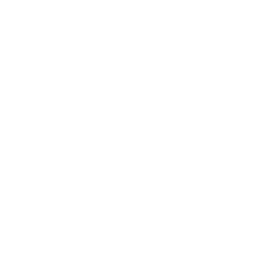
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">病院部門の資源利用状況 — 横棒グラフ</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; ヘルスケア / 病院運営 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

この例では **PROC GCHART** の水平棒グラフ（HBAR）を用いて、2026年第1四半期における6つの臨床部門の勤務時間を分析します。**90件のシフト記録**（各部門15件）から成る合成勤務ログが、3つのビュー — 総時間による順位付け棒グラフ、部門別平均シフト時間、そして職種別・シフト別にグループ化されたHBAR — を駆動します。`SUMVAR=` はレコード数ではなく実際の労働時間を集計し、`TYPE=SUM`/`TYPE=MEAN` は応答統計量を切り替え、`DESCENDING` は部門を順位付けし、`GROUP=` は第2の次元のために隣接するクラスタ化棒を描画します。

この出力は四半期の業務効率レビューを支えます。すなわち、どの部門が最も多くの労働力を消費しているか、どの部門が最も長いシフトを組んでいるか、そして日勤／準夜勤／夜勤の人員配置パターンが、24時間体制の部門と日中中心のサービスとでどう異なるかを明らかにします。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------|
| WORK.STAFFING_LOG | 勤務時間を含む個々のシフト労務記録 | 90 |
| WORK.DEPT_SUMMARY | 部門レベルの合計と平均シフト時間 | 6 |

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic hospital staffing labor log.
   Q1 2026: 6 clinical departments, 4 resource categories,
   3 shifts. Sized to 15 shift records per department
   (90 total) so the full department roster stays visible.
   -------------------------------------------------------- */
データ work.staffing_log;
    呼出 streaminit(20260601);
    長さ department $24 resource_type $24 shift $12;
    見出 department="診療科" resource_type="職種" shift="シフト"
          hours_worked="労働時間（時間）";

    /* resource-category mix (nursing-heavy clinical staffing) */
    配列 resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* baseline shift mix, tilted toward Night for 24/7 units */
    配列 shfw[3] _temporary_ (0.45 0.30 0.25);
    配列 nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    繰返 di = 1 から 6;
        もし      di = 1 なら department = "救急科";
        他 もし di = 2 なら department = "外科";
        他 もし di = 3 なら department = "ICU";
        他 もし di = 4 なら department = "小児科";
        他 もし di = 5 なら department = "腫瘍科";
        他             department = "産科";
        繰返 rec = 1 から 15;

            /* resource type via weighted draw */
            u = rand('uniform'); cum = 0;
            繰返 r = 1 から 4;
                cum + resw[r];
                もし u <= cum なら 繰返;
                    もし      r = 1 なら resource_type = "看護";
                    他 もし r = 2 なら resource_type = "医師";
                    他 もし r = 3 なら resource_type = "コメディカル";
                    他               resource_type = "支援";
                    脱出;
                終了;
            終了;

            /* shift via department-specific night tilt */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            もし u <= w1 なら shift = "日勤";
            他 もし u <= w1 + w2 なら shift = "準夜勤";
            他 shift = "夜勤";

            /* hours: physicians and surgery run longer shifts */
            BASE = 8;
            もし resource_type = "医師" なら BASE = BASE + 1.5;
            もし department = "外科"      なら BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            もし hours_worked < 4 なら hours_worked = 4;

            出力;
        終了;
    終了;
    保持 department resource_type shift hours_worked;
実行;



NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Department-level totals and mean shift length,
   ranked by total labor hours.
   -------------------------------------------------------- */
処理 SQL;
    CREATE TABLE work.dept_summary AS
    選択 department,
           sum(hours_worked)  AS total_hours   書式=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  書式=6.2
    FROM work.staffing_log
    GROUP 基準 department
    ORDER 基準 total_hours DESC;
QUIT;

処理 印刷 データ=work.dept_summary noobs 見出;
    見出 department    = "診療科"
          total_hours   = "総時間数"
          shift_count   = "シフト数"
          avg_shift_hrs = "平均シフト時間（時間）";
    表題 "部門別労務時間サマリー - 2026年第1四半期";
実行;
表題;


                                                部門別労務時間サマリー - 2026年第1四半期                                                

      診療科          総時間数          シフト数                        平均シフト時間（時間）
外科               136.25            15                               9.08
ICU              128.50            15                               8.57
産科               127.75            15                               8.52
小児科              124.75            15                               8.32
腫瘍科              123.75            15                               8.25
救急科              119.25            15                               7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                                        部門別労務時間                                                         

                                                  The MEANS Procedure

                               Analysis Variable : hours_worked 労働時間（時間）

        診療科                  Sum           Mean          N Obs
        ------------------------------------------------------
        ICU               128.50           8.57             15
        外科                136.25           9.08             15
        小児科               124.75           8.32             15
        救急科               119.25           7.95             15
        産科                127.75           8.52             15
        腫瘍科               123.75           8.25             15
        ------------------------------------------------------

                                                        部門別シフト分布                                                        

                                           


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


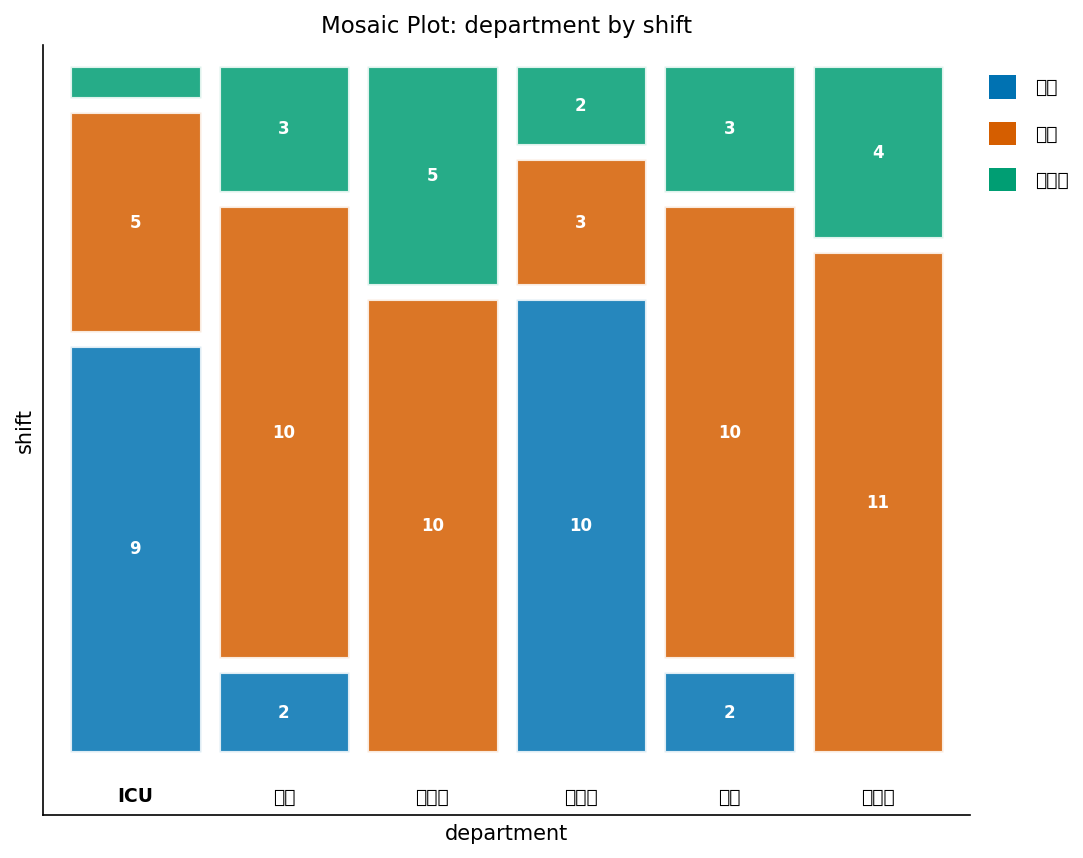

In [3]:
/* --------------------------------------------------------
   Baseline tables: labor hours by department, and the
   day / swing / night shift distribution per department.
   -------------------------------------------------------- */
処理 平均 データ=work.staffing_log sum mean n maxdec=2;
    分類 department;
    変数 hours_worked;
    表題 "部門別労務時間";
実行;

処理 度数 データ=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    表題 "部門別シフト分布";
実行;
表題;


---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


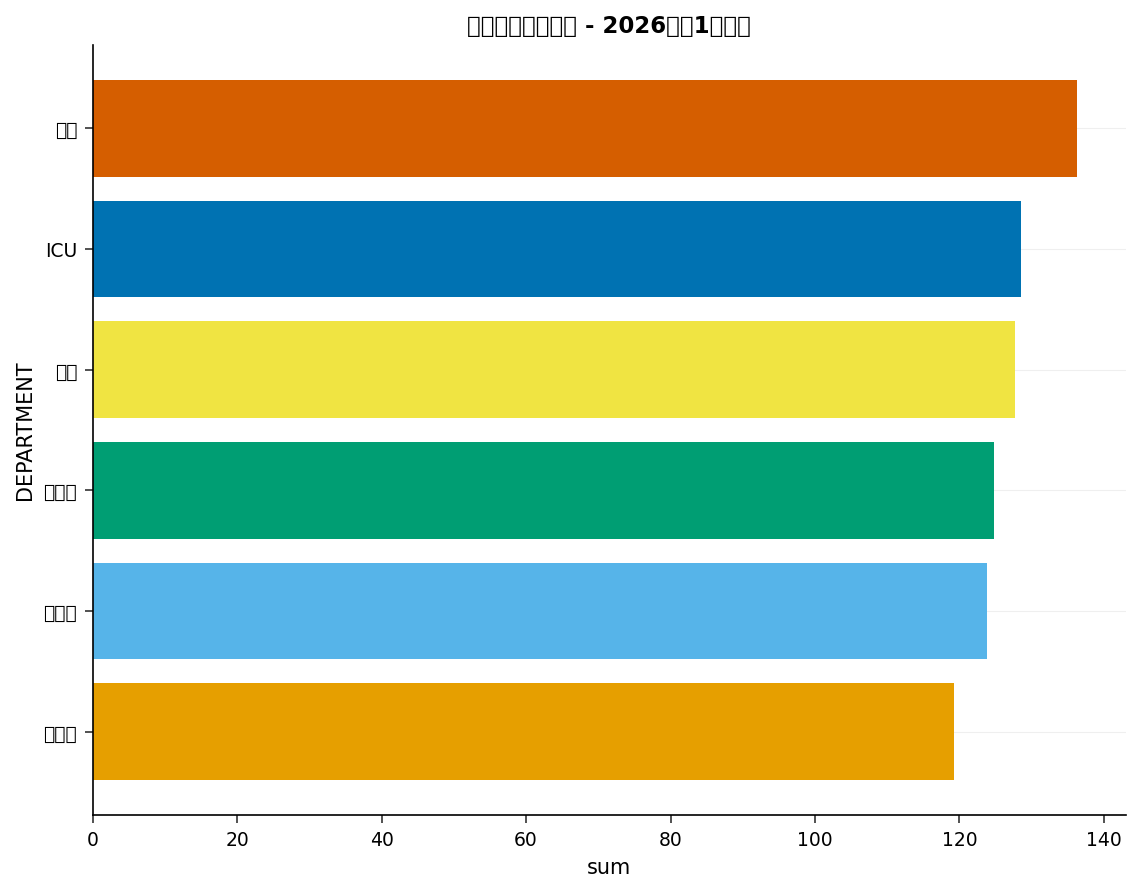

In [4]:
/* --------------------------------------------------------
   Overview HBAR: total labor hours by department.
   SUMVAR= accumulates hours; DESCENDING ranks the bars.
   -------------------------------------------------------- */
処理 GCHART データ=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      DESCENDING;
    表題 "部門別総労務時間 - 2026年第1四半期";
実行;
QUIT;
表題;


### 職種別に部門を分割する

`GROUP=` は各部門について、職種ごとに1本の棒から成る隣接クラスタを描画します。`SUMVAR=hours_worked` が有効なため、各棒はレコード数ではなく積算労働時間を測定し、看護・医師・コメディカル・支援の各時間が部門*内*でどう比較されるかを示します。

In [5]:
/* --------------------------------------------------------
   PATTERN statements: coordinated 4-color palette
   one pattern per resource type subgroup
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Nursing — deep blue   */
pattern2 VALUE=solid color=cx28A745;   /* Physician — green     */
pattern3 VALUE=solid color=cxE8650A;   /* Allied Health — amber */
pattern4 VALUE=solid color=cx6C757D;   /* Support Staff — gray  */


                                                       職種別部門労務時間                                                        


出典：勤怠管理システム | 対象期間：2026年1月～3月



NOTE: Option TITLE changed to 職種別部門労務時間.
NOTE: Option FOOTNOTE changed to 出典：勤怠管理システム | 対象期間：2026年1月～3月.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


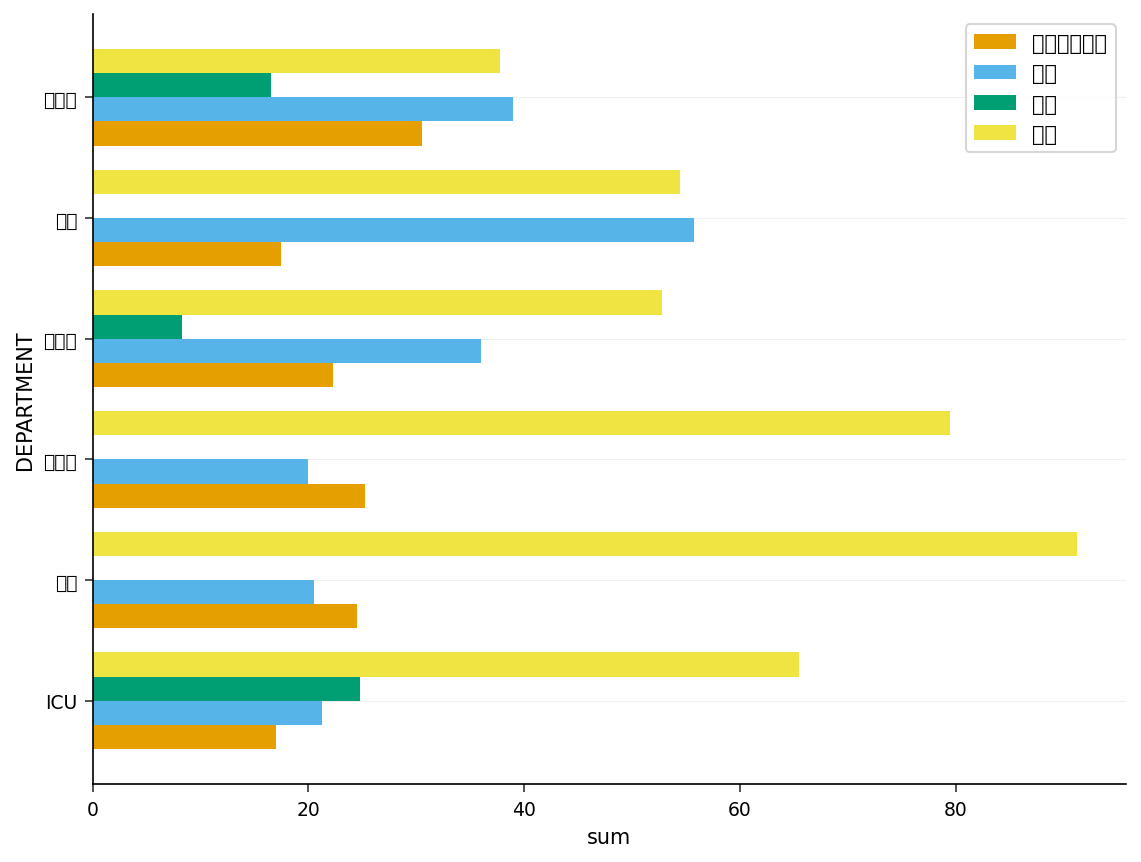

In [6]:
/* --------------------------------------------------------
   HBAR grouped by resource category (GROUP=).
   Each department becomes a cluster of bars -- one per
   resource type -- measured in accumulated labor hours.
   -------------------------------------------------------- */
表題 "職種別部門労務時間";
footnote JUSTIFY=LEFT
    "出典：勤怠管理システム | 対象期間：2026年1月～3月";

処理 GCHART データ=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
実行;
QUIT;

表題; footnote;


                                                       シフト別部門労務時間                                                       


グループ化された棒は、部門ごとに日勤・準夜勤・夜勤の内訳を分けて示します



NOTE: Option TITLE changed to シフト別部門労務時間.
NOTE: Option FOOTNOTE changed to グループ化された棒は、部門ごとに日勤・準夜勤・夜勤の内訳を分けて示します.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


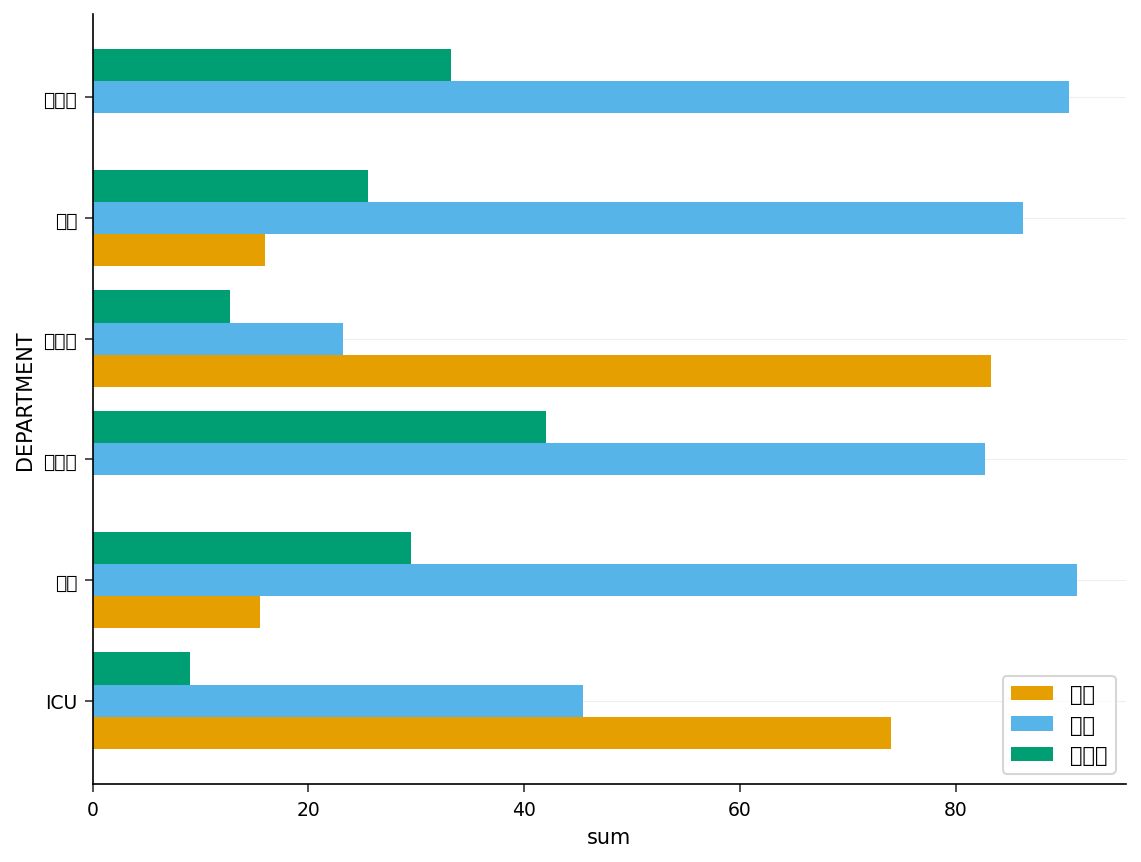

In [7]:
/* --------------------------------------------------------
   HBAR grouped by shift (GROUP=).
   Separates Day / Swing / Night labor hours within each
   department -- highlighting the 24/7 acuity units.
   -------------------------------------------------------- */
表題 "シフト別部門労務時間";
footnote JUSTIFY=LEFT
    "グループ化された棒は、部門ごとに日勤・準夜勤・夜勤の内訳を分けて示します";

処理 GCHART データ=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
実行;
QUIT;

表題; footnote;



NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


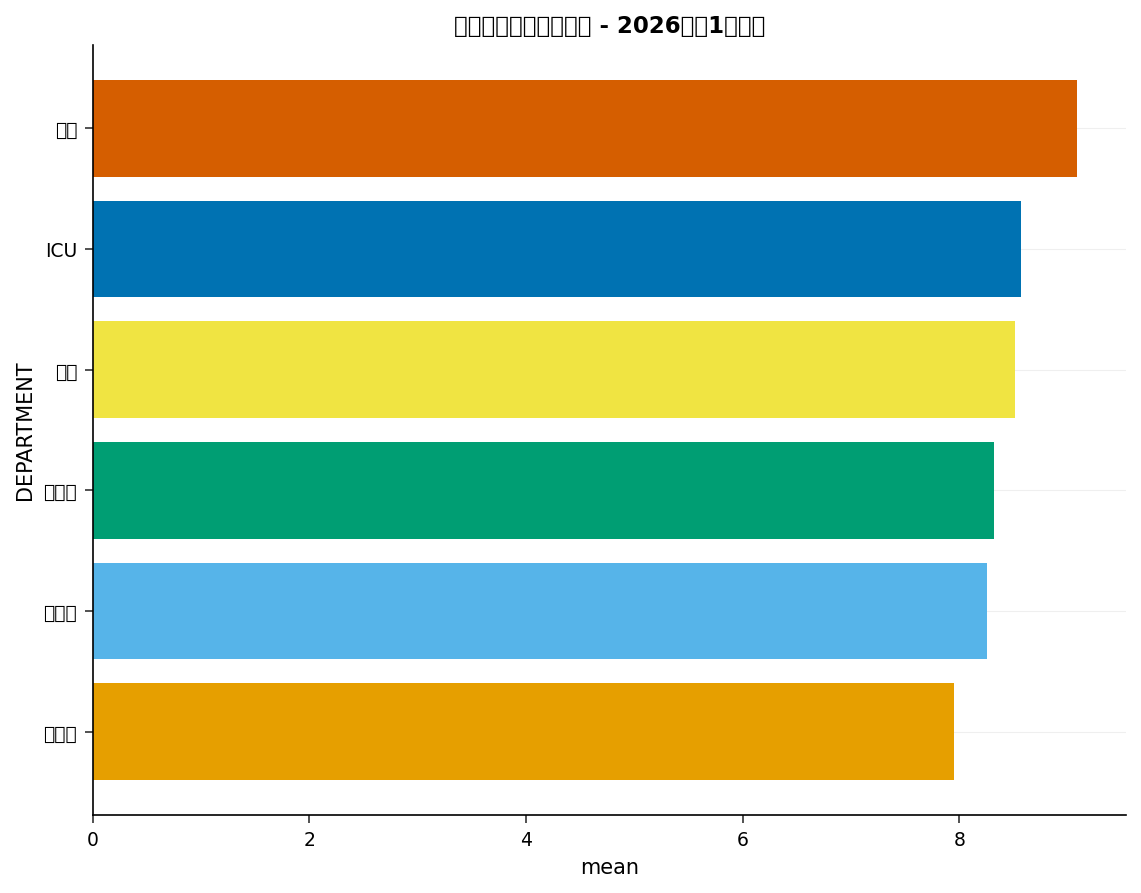

In [8]:
/* --------------------------------------------------------
   Mean shift length per department (TYPE=MEAN).
   Reveals whether a department runs long shifts or many
   shorter ones, independent of total volume.
   -------------------------------------------------------- */
処理 GCHART データ=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      DESCENDING;
    表題 "部門別平均シフト時間 - 2026年第1四半期";
実行;
QUIT;
表題;


---

### 解釈

90件のシフト記録全体で、総労働時間は**119.25時間**（救急科）から**136.25時間**（外科）という狭い範囲に収まっています。これは、この期間中どの部門も同じ15シフトを担当しているためです — つまり順位はシフト数ではなく**シフトの長さ**を反映しています。外科は総時間のグラフと平均シフトのグラフの両方でトップとなり、1シフトあたり**9.08時間**です。これは、より長い手術症例と、それに伴う医師中心の人員配置と整合します。救急科は、最も忙しい部門の一つであるにもかかわらず、労働時間では最下位（平均**7.95時間**）です。これは、より短く、より回転率の高いシフトで業務がこなされているためです。

シフト別にグループ化されたHBARとモザイクパネルは、業務上重要な物語を伝えます。**救急科とICUは夜勤中心**です — それぞれ15シフト中10シフト、9シフトが夜勤です — 一方で**腫瘍科と小児科はまったく夜勤がなく**、日勤に集中しています（それぞれ11シフト、10シフトが日勤）。この分かれ方は実際の病院の人員配置を反映しています。24時間体制の部門は昼夜を問わず稼働する一方、腫瘍科の点滴治療や一般小児科は日中のサービスです。職種別のパネルは、すべての部門で**看護中心の構成**を裏づけており、医師とコメディカルの時間は次に多い層を形成しています。

第2四半期の人員配置レビューにおいて、救急科とICUにおける夜勤の集中は注視すべき項目です。これは割増賃金と疲労管理のコストが蓄積される場所であり、シフト編成の変更が予算に最も大きな影響を与える場所でもあります。

---

In [9]:
/* --------------------------------------------------------
   Export the department summary for the workforce
   planning system.
   -------------------------------------------------------- */
処理 EXPORT データ=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
実行;



NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供元 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>